# IMU 축 순열·부호 전수조사 (48가지)

samsung2(target) IMU `triceps_X/Y/Z` 를 **6 축순열 × 8 부호 = 48조합** 으로 갈아끼우고,
각 조합의 **MM source-only 정확도**를 모두 뽑는다. (gravity 정렬과 무관한 순수 이산 탐색 기준선)

- 정렬 의미: `order='YXZ'` → 새 `triceps_X ← 기존 triceps_Y` ... / `signs` 는 각 슬롯 부호.
- `XYZ_+++` = raw(항등), `YXZ_+++` = 우리가 쓰던 수동 X↔Y swap.
- ⚠ 무거움: `evaluate_accuracy_mm` 48회(~각 40초 ≈ 30분). 멈추면 커널 재시작 후 순서대로.
- 환경: conda env **DA**.

In [1]:
# ── 셋업: MM source-only 모델 + EMG 전처리 1회 캐시 ──
import os, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from tqdm import tqdm

ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)
# eval_utils 가 전처리기를 함수 안에서 lazy import 하므로 전처리 모듈도 함께 강제 reload.
import eval_utils as U
for _m in ('data_preprocess_MM_original', 'eval_utils'):
    if _m in sys.modules:
        importlib.reload(sys.modules[_m])
importlib.reload(U)

model  = U.load_mm_model(os.path.join(ROOT, 'weights', 'mm_no_da_seed42_best_model.pth'))
df_tgt = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung2_original.parquet'))

# EMG(+1000Hz 리샘플) 전처리를 여기서 딱 1회만 수행 → 48조합에서 IMU 변환만 반복 재사용.
cache = U.MMEvalCache(df_tgt, model=model)
print('셋업 완료 |', model.__class__.__name__, '| 캐시 윈도우', cache.n_windows)

셋업 완료 | InterFusionClassifier | 캐시 윈도우 21629


In [2]:
# ── 48조합 전수조사 (IMU 변환만 반복; EMG/리샘플은 캐시 재사용) ──
# order='YXZ' → 새 triceps_X ← 기존 triceps_Y ...  를 캐시된 (T,3) IMU 에 그대로 적용.
AX = {'X': 0, 'Y': 1, 'Z': 2}
rows = []
for name, order, signs in tqdm(list(U.iter_imu_permutations()), desc='48조합'):
    idx = [AX[c] for c in order]; sg = np.asarray(signs, float)
    acc = cache.accuracy(lambda a, idx=idx, sg=sg: a[:, idx] * sg)
    rows.append({'name': name, 'order': order,
                 'signs': ''.join('+' if s > 0 else '-' for s in signs),
                 'acc': round(acc, 2)})

res = pd.DataFrame(rows).sort_values('acc', ascending=False).reset_index(drop=True)
res.to_csv(os.path.join(ROOT, 'results', 'imu_permutation_bruteforce.csv'), index=False)
print('저장: results/imu_permutation_bruteforce.csv')

48조합: 100%|██████████| 48/48 [04:52<00:00,  6.10s/it]

저장: results/imu_permutation_bruteforce.csv


raw(XYZ_+++)      = 20.49%
수동 YXZ(YXZ_+++) = 59.03%
48조합 best        = YXZ_++-  65.77%

[상위 10]


,name,order,signs,acc
0,YXZ_++-,YXZ,++-,65.77
1,YZX_+--,YZX,+--,62.82
2,YXZ_+++,YXZ,+++,59.03
3,YZX_++-,YZX,++-,44.26
4,YZX_+-+,YZX,+-+,37.02
5,XYZ_---,XYZ,---,32.44
6,ZXY_-++,ZXY,-++,30.33
7,XYZ_--+,XYZ,--+,29.02
8,XZY_+--,XZY,+--,27.60
9,XZY_-++,XZY,-++,27.21


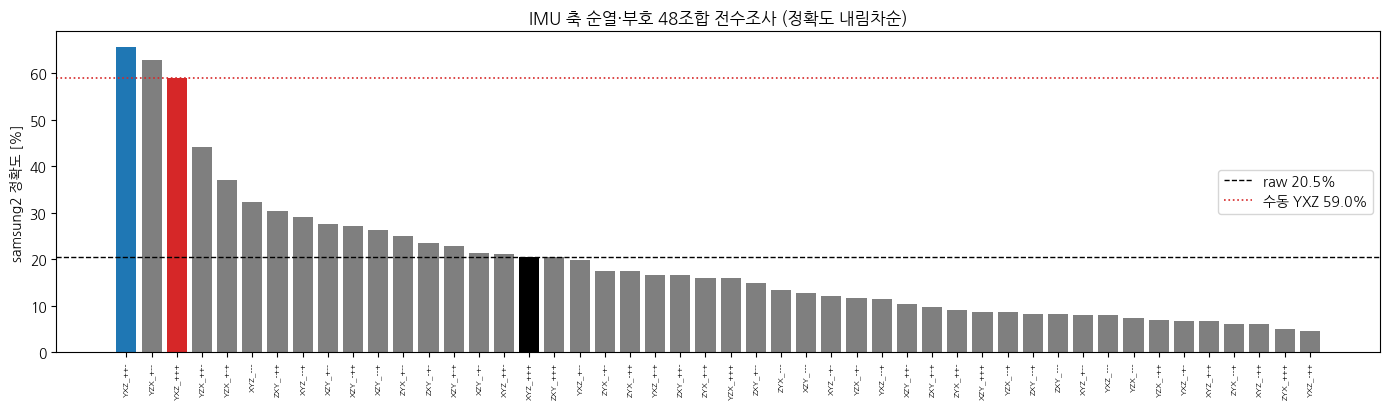

In [3]:
# ── 결과: 상위/기준 조합 + 전체 막대 ──
raw_acc = res.loc[res.name == 'XYZ_+++', 'acc'].iloc[0]   # 항등(raw)
yxz_acc = res.loc[res.name == 'YXZ_+++', 'acc'].iloc[0]   # 수동 X↔Y swap
best    = res.iloc[0]
print(f'raw(XYZ_+++)      = {raw_acc:.2f}%')
print(f'수동 YXZ(YXZ_+++) = {yxz_acc:.2f}%')
print(f'48조합 best        = {best["name"]}  {best.acc:.2f}%')
print('\n[상위 10]'); display(res.head(10))

fig, ax = plt.subplots(figsize=(14, 4.2))
x = np.arange(len(res))
colors = ['tab:gray'] * len(res)
for i, nm in enumerate(res.name):
    if nm == 'XYZ_+++': colors[i] = 'black'
    elif nm == 'YXZ_+++': colors[i] = 'tab:red'
    elif i == 0: colors[i] = 'tab:blue'
ax.bar(x, res.acc, color=colors)
ax.axhline(raw_acc, color='black',   ls='--', lw=1, label=f'raw {raw_acc:.1f}%')
ax.axhline(yxz_acc, color='tab:red', ls=':',  lw=1.2, label=f'수동 YXZ {yxz_acc:.1f}%')
ax.set_xticks(x); ax.set_xticklabels(res.name, rotation=90, fontsize=6)
ax.set_ylabel('samsung2 정확도 [%]')
ax.set_title('IMU 축 순열·부호 48조합 전수조사 (정확도 내림차순)')
ax.legend(); plt.tight_layout(); plt.show()